In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [ ]:
image_path = "../output_videos/cropped_image.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

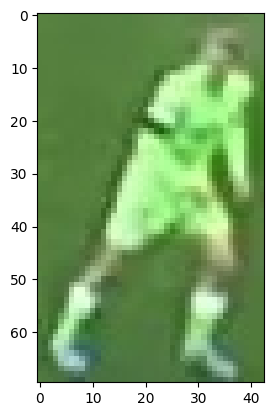

In [ ]:
plt.imshow(image)
plt.show()

# Take the Top Half of the Image

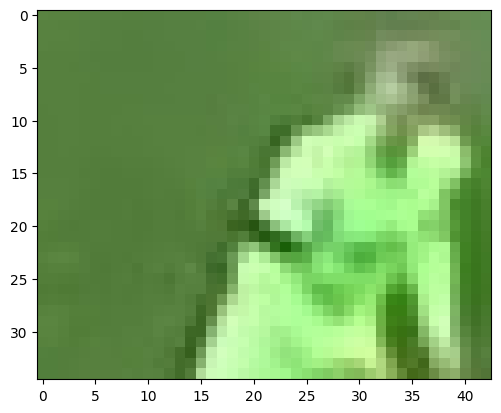

In [ ]:
top_half_image = image[0:int(image.shape[0]//2), :]
plt.imshow(top_half_image)
plt.show()

# Cluster the image into Two Clusters

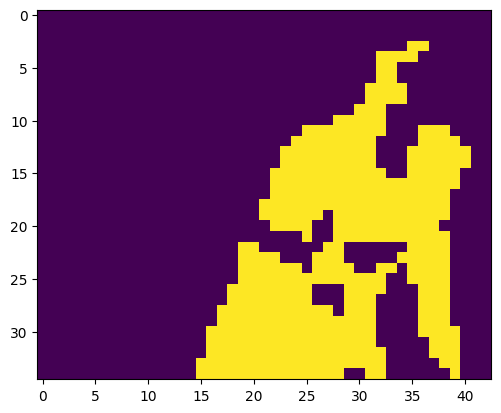

In [ ]:
# Reshape the image into 2d array
image_2d = top_half_image.reshape(-1, 3)

# Perform k-means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

# Get the cluster labels
labels = kmeans.labels_

# Reshape the labels into the original image shape
clustered_image = labels.reshape(top_half_image.shape[0], top_half_image.shape[1])

# Diplay the clustered image
plt.imshow(clustered_image)
plt.show()


In [ ]:
corner_cluster = [clustered_image[0,0], clustered_image[0,-1], clustered_image[-1,0], clustered_image[-1,-1]]
non_player_cluster = max(set(corner_cluster), key=corner_cluster.count) 
print(non_player_cluster)  

0


In [ ]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [ ]:
kmeans.cluster_centers_[player_cluster]

array([169.31111111, 233.46419753, 143.52098765])